# Introduction to SSM Analysis

This notebook provides an introduction to Structural Summary Method (SSM) analysis using the circumplex package.

In [1]:
from great_tables import GT

from circumplex import load_dataset, ssm_analyze

## 1. Loading Example Data: jz2017

We'll use the `jz2017` dataset from Zimmermann & Wright (2017). This dataset includes self-report data from 1166 undergraduate students who completed:

- A circumplex measure of interpersonal problems (IIP-SC) with eight subscales: PA, BC, DE, FG, HI, JK, LM, NO
- A measure of personality disorder symptoms with ten subscales: PARPD, SCZPD, SZTPD, ASPD, BORPD, HISPD, NARPD, AVPD, DPNPD, OCPD

In [2]:
jz2017 = load_dataset("jz2017")
GT(jz2017.head())

Gender,PA,BC,DE,FG,HI,JK,LM,NO,PARPD,SCZPD,SZTPD,ASPD,BORPD,HISPD,NARPD,AVPD,DPNPD,OCPD
Female,1.5,1.5,1.25,1.0,2.0,2.5,2.25,2.5,4,3,7,7,8,4,6,3,4,6
Female,0.0,0.25,0.0,0.25,1.25,1.75,2.25,2.25,1,0,2,0,1,2,3,0,1,0
Female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,4,1,5,4,0,0,1
Male,2.0,1.75,1.75,2.5,2.0,1.75,2.0,2.5,1,0,0,0,1,0,0,0,0,0
Female,0.25,0.5,0.25,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,0,1,0,0


## 2. Mean-Based SSM Analysis

### Single Group Analysis

Let's analyze the interpersonal problems of the average individual in the dataset using `ssm_analyze()`. The function returns an SSM object with results, scores, and analysis details.

In [3]:
# Define circumplex scales and their angular positions
scales = ["PA", "BC", "DE", "FG", "HI", "JK", "LM", "NO"]
angles = [90, 135, 180, 225, 270, 315, 360, 45]

# Run SSM analysis
results = ssm_analyze(data=jz2017, scales=scales, angles=angles)

# Display summary
results.summary()

Statistical Basis:   Mean Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                  Profile[All]                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.917    │ 0.889    │ 0.945    │
│ X-Value      │ 0.351    │ 0.323    │ 0.378    │
│ Y-Value      │ -0.252   │ -0.281   │ -0.223   │
│ Amplitude    │ 0.432    │ 0.402    │ 0.46     │
│ Displacement │ 324.292  │ 320.757  │ 327.79   │
│ Model Fit    │ 0.878    │          │          │
└──────────────┴──────────┴──────────┴──────────┘

### Accessing Results

The SSM object provides easy access to results, scores, and analysis details:

In [26]:
# View results DataFrame with parameter estimates and confidence intervals
GT(results.results.round(2))

Label,Group,Measure,e_est,e_lci,e_uci,x_est,x_lci,x_uci,y_est,y_lci,y_uci,a_est,a_lci,a_uci,d_est,d_lci,d_uci,fit_est
All,All,,0.92,0.89,0.95,0.35,0.32,0.38,-0.25,-0.28,-0.22,0.43,0.4,0.46,324.29,320.76,327.79,0.88


In [27]:
# View scores DataFrame
GT(results.scores.round(2))

Label,PA,BC,DE,FG,HI,JK,LM,NO
All,0.55,0.58,0.62,0.76,1.21,1.21,1.48,0.9


In [6]:
# View analysis details
print(f"Analysis type: {results.type}")
print(f"Angles: {results.details.angles}")
print(f"Bootstrap resamples: {results.details.boots}")
print(f"Confidence level: {results.details.interval}")

Analysis type: mean
Angles: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]
Bootstrap resamples: 2000
Confidence level: 0.95


## 3. Visualizing SSM Results

The circumplex package provides three visualization functions:

1. **Circle Plot**: Shows amplitude and displacement on a circular plot
2. **Curve Plot**: Shows fitted cosine curves overlaid on observed scores  
3. **Contrast Plot**: Shows parameter differences between groups (for contrast analyses)

### Circle Plot

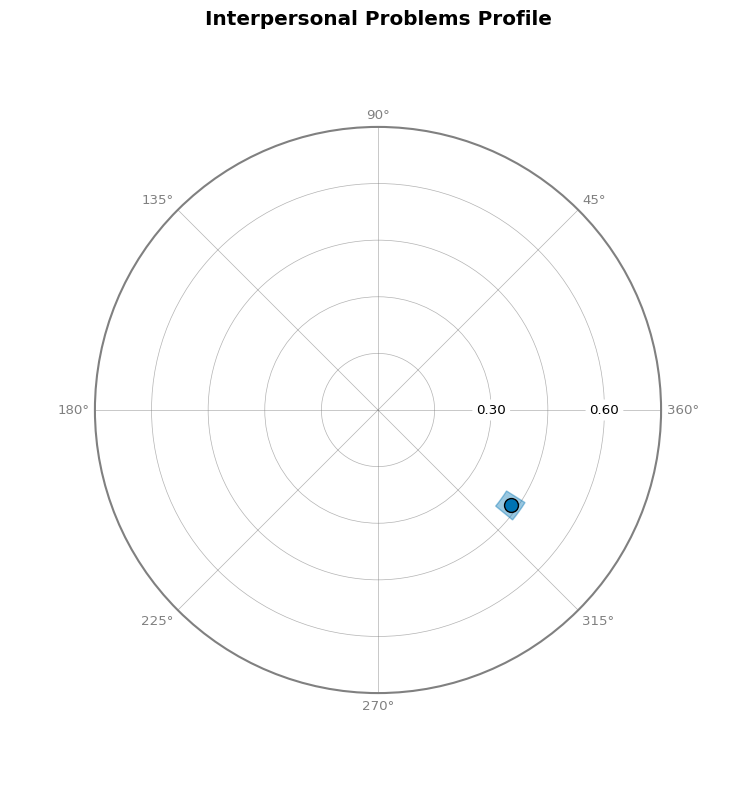

In [7]:
# Create circle plot
fig = results.plot_circle(title="Interpersonal Problems Profile")

### Curve Plot

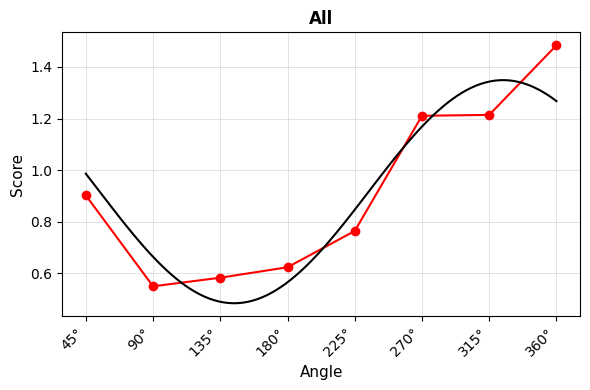

In [8]:
# Create curve plot showing observed scores and fitted curve
fig = results.plot_curve()

## 4. Correlation-Based SSM Analysis

To examine how personality disorder symptoms relate to interpersonal problems, we can perform correlation-based SSM analysis by specifying external measures.

In [9]:
# Analyze narcissistic personality disorder symptoms
results_corr = ssm_analyze(
    data=jz2017,
    scales=scales,
    angles=angles,
    measures="NARPD",
)

results_corr.summary()

Statistical Basis:   Correlation Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                 Profile[NARPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.202    │ 0.167    │ 0.237    │
│ X-Value      │ -0.062   │ -0.094   │ -0.029   │
│ Y-Value      │ 0.179    │ 0.145    │ 0.212    │
│ Amplitude    │ 0.189    │ 0.155    │ 0.224    │
│ Displacement │ 108.967  │ 99.221   │ 118.54   │
│ Model Fit    │ 0.957    │          │          │
└──────────────┴──────────┴──────────┴──────────┘

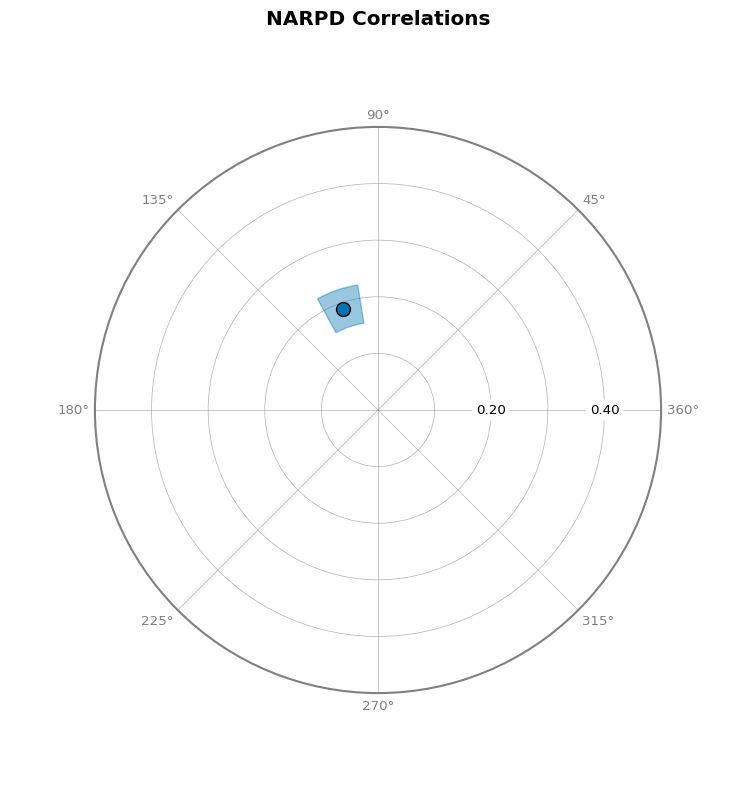

In [10]:
# Visualize correlation-based results
fig = results_corr.plot_circle(title="NARPD Correlations")

## 5. Group Comparisons

### Multiple Groups

In [11]:
# Analyze by gender
results_group = ssm_analyze(
    data=jz2017,
    scales=scales,
    angles=angles,
    grouping="Gender",
)

results_group.summary()

Statistical Basis:   Mean Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                 Profile[Female]                 
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.946    │ 0.908    │ 0.984    │
│ X-Value      │ 0.459    │ 0.421    │ 0.497    │
│ Y-Value      │ -0.31    │ -0.356   │ -0.268   │
│ Amplitude    │ 0.554    │ 0.511    │ 0.599    │
│ Displacement │ 325.963  │ 321.939  │ 329.811  │
│ Model Fit    │ 0.889    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
                  Profile[Male]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.884    │ 0.842    │ 0.926    │
│ X-Value      │ 0.227    │ 0.192    │ 0.261    │
│ Y-Value      │ -0.186   │ -0.225   │ -0.148   │
│ Amplitude    │ 0.294    │ 0.258    │ 0.33     │
│ Displacement │ 320.685  │ 313.649  │ 328.014  │
│ Model Fit    │ 0.824    │          │          │
└──────────────┴──────────┴──────────┴──────────┘

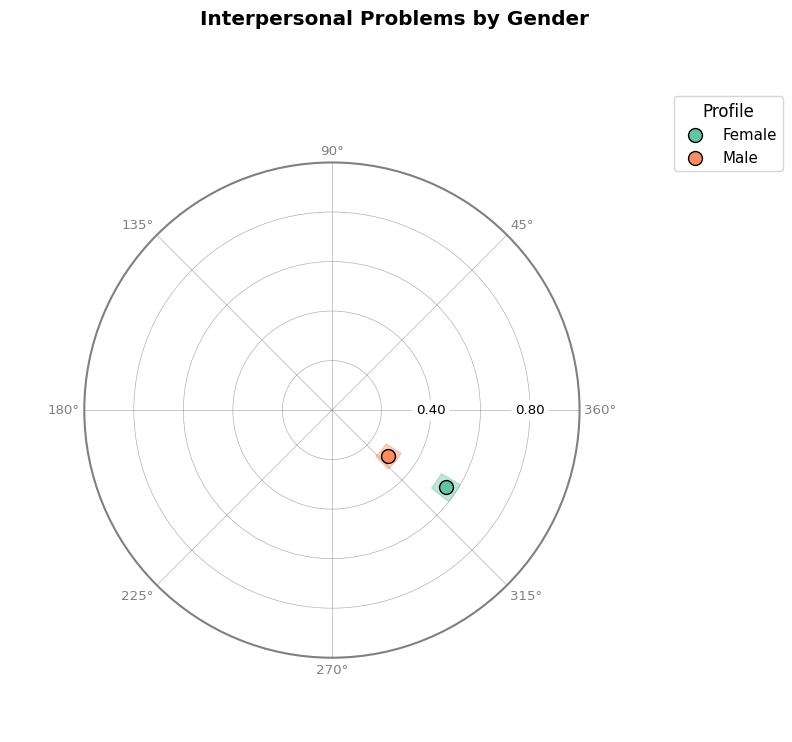

In [12]:
# Compare groups on circle plot
fig = results_group.plot_circle(colors="Set2", title="Interpersonal Problems by Gender")

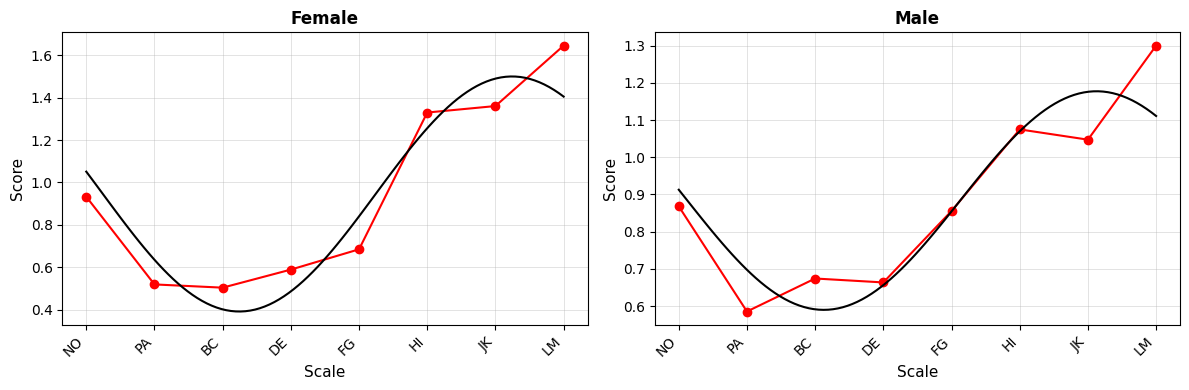

In [13]:
# Compare groups with curve plots
fig = results_group.plot_curve(angle_labels=scales)

### Multiple Measures

In [14]:
# Compare multiple personality disorder symptoms
results_multi = ssm_analyze(
    data=jz2017,
    scales=scales,
    angles=angles,
    measures=["NARPD", "ASPD", "BORPD"],
)

results_multi.summary()

Statistical Basis:   Correlation Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                 Profile[NARPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.202    │ 0.168    │ 0.238    │
│ X-Value      │ -0.062   │ -0.094   │ -0.03    │
│ Y-Value      │ 0.179    │ 0.143    │ 0.211    │
│ Amplitude    │ 0.189    │ 0.154    │ 0.223    │
│ Displacement │ 108.967  │ 99.472   │ 118.732  │
│ Model Fit    │ 0.957    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
                  Profile[ASPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.124    │ 0.089    │ 0.159    │
│ X-Value      │ -0.099   │ -0.133   │ -0.062   │
│ Y-Value      │ 0.203    │ 0.168    │ 0.237    │
│ Amplitude    │ 0.226    │ 0.191    │ 0.262    │
│ Displacement │ 115.927  │ 106.85   │ 124.367  │
│ Model Fit    │ 0.964    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
                 Profile[BORPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.277    │ 0.243    │ 0.31     │
│ X-Value      │ -0.036   │ -0.069   │ -0.004   │
│ Y-Value      │ 0.097    │ 0.056    │ 0.138    │
│ Amplitude    │ 0.103    │ 0.064    │ 0.146    │
│ Displacement │ 110.358  │ 92.848   │ 130.012  │
│ Model Fit    │ 0.872    │          │          │
└──────────────┴──────────┴──────────┴──────────┘

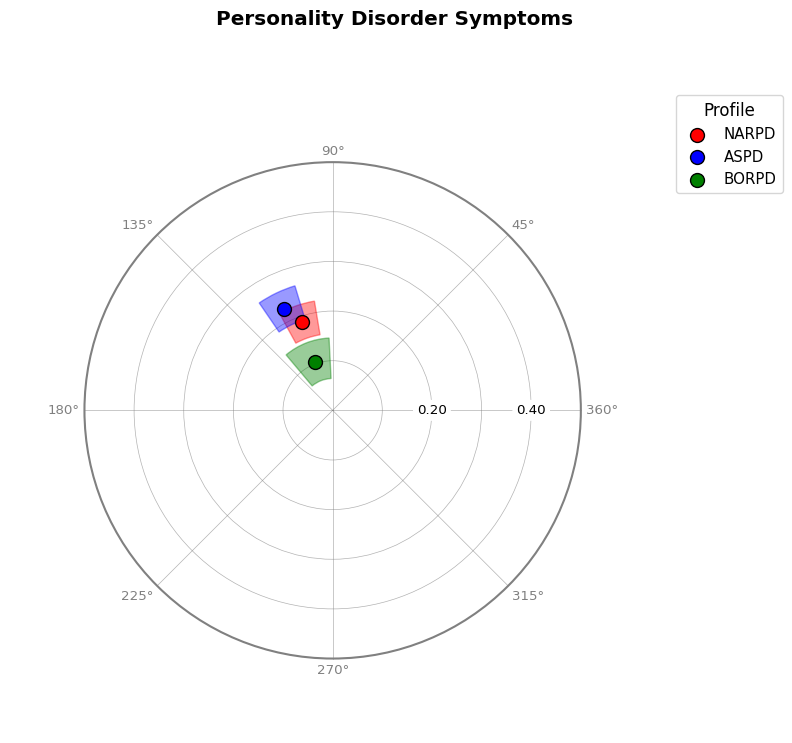

In [15]:
# Visualize multiple measures
fig = results_multi.plot_circle(
    colors=["red", "blue", "green"], title="Personality Disorder Symptoms"
)

## 6. Contrast Analyses

### Group Contrasts

To test whether groups differ significantly on SSM parameters, use `contrast=True`:

In [16]:
# Contrast analysis between genders
results_contrast = ssm_analyze(
    data=jz2017,
    scales=scales,
    angles=angles,
    grouping="Gender",
    contrast=True,
)

results_contrast.summary()

Statistical Basis:   Mean Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                 Profile[Female]                 
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.946    │ 0.906    │ 0.983    │
│ X-Value      │ 0.459    │ 0.422    │ 0.496    │
│ Y-Value      │ -0.31    │ -0.352   │ -0.267   │
│ Amplitude    │ 0.554    │ 0.512    │ 0.599    │
│ Displacement │ 325.963  │ 322.128  │ 329.684  │
│ Model Fit    │ 0.889    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
                  Profile[Male]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.884    │ 0.842    │ 0.927    │
│ X-Value      │ 0.227    │ 0.191    │ 0.263    │
│ Y-Value      │ -0.186   │ -0.223   │ -0.147   │
│ Amplitude    │ 0.294    │ 0.258    │ 0.33     │
│ Displacement │ 320.685  │ 313.831  │ 327.899  │
│ Model Fit    │ 0.824    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
             Profile[Male - Female]              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ -0.062   │ -0.118   │ -0.004   │
│ X-Value      │ -0.232   │ -0.282   │ -0.18    │
│ Y-Value      │ 0.124    │ 0.068    │ 0.18     │
│ Amplitude    │ -0.261   │ -0.317   │ -0.203   │
│ Displacement │ -5.278   │ 347.143  │ 2.851    │
│ Model Fit    │ -0.066   │          │          │
└──────────────┴──────────┴──────────┴──────────┘

In [28]:
# View contrast results (last row shows Male - Female differences)
GT(results_contrast.results.round(2))

Label,Group,Measure,e_est,e_lci,e_uci,x_est,x_lci,x_uci,y_est,y_lci,y_uci,a_est,a_lci,a_uci,d_est,d_lci,d_uci,fit_est
Female,Female,,0.95,0.91,0.98,0.46,0.42,0.5,-0.31,-0.35,-0.27,0.55,0.51,0.6,325.96,322.13,329.68,0.89
Male,Male,,0.88,0.84,0.93,0.23,0.19,0.26,-0.19,-0.22,-0.15,0.29,0.26,0.33,320.68,313.83,327.9,0.82
Male - Female,Male - Female,,-0.06,-0.12,-0.0,-0.23,-0.28,-0.18,0.12,0.07,0.18,-0.26,-0.32,-0.2,-5.28,347.14,2.85,-0.07


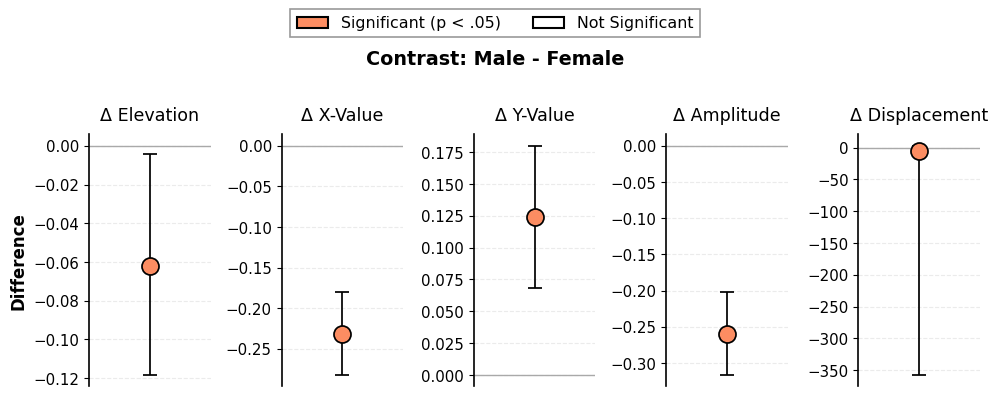

In [18]:
# Visualize contrasts
fig = results_contrast.plot_contrast()

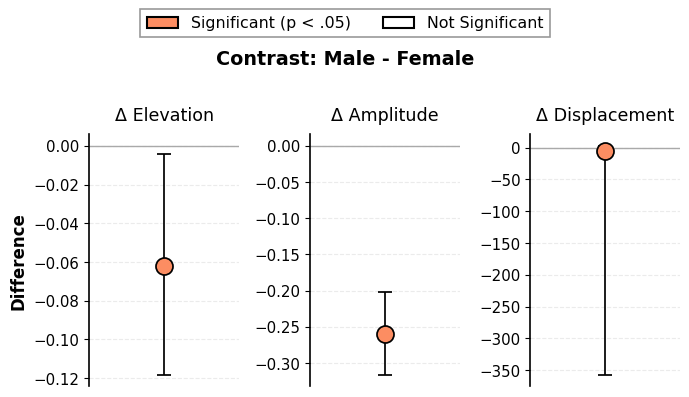

In [19]:
# Simplified contrast plot (drop X and Y parameters)
fig = results_contrast.plot_contrast(drop_xy=True)

### Measure Contrasts

In [20]:
# Compare two measures
results_meas_contrast = ssm_analyze(
    data=jz2017,
    scales=scales,
    angles=angles,
    measures=["NARPD", "ASPD"],
    contrast=True,
)

results_meas_contrast.summary()

Statistical Basis:   Correlation Scores
Bootstrap Resamples: 2000
Confidence Level:    0.95
Listwise Deletion:   True
Scale Displacements: [90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0, 45.0]


                 Profile[NARPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.202    │ 0.169    │ 0.235    │
│ X-Value      │ -0.062   │ -0.094   │ -0.028   │
│ Y-Value      │ 0.179    │ 0.146    │ 0.212    │
│ Amplitude    │ 0.189    │ 0.156    │ 0.224    │
│ Displacement │ 108.967  │ 99.04    │ 118.521  │
│ Model Fit    │ 0.957    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
                  Profile[ASPD]                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ 0.124    │ 0.088    │ 0.16     │
│ X-Value      │ -0.099   │ -0.135   │ -0.063   │
│ Y-Value      │ 0.203    │ 0.169    │ 0.238    │
│ Amplitude    │ 0.226    │ 0.19     │ 0.262    │
│ Displacement │ 115.927  │ 107.14   │ 124.123  │
│ Model Fit    │ 0.964    │          │          │
└──────────────┴──────────┴──────────┴──────────┘
              Profile[ASPD - NARPD]              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃              ┃ Estimate ┃ Lower CI ┃ Upper CI ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Elevation    │ -0.079   │ -0.117   │ -0.04    │
│ X-Value      │ -0.037   │ -0.076   │ 0.001    │
│ Y-Value      │ 0.024    │ -0.012   │ 0.062    │
│ Amplitude    │ 0.037    │ -0.001   │ 0.077    │
│ Displacement │ 6.96     │ 356.639  │ 17.454   │
│ Model Fit    │ 0.007    │          │          │
└──────────────┴──────────┴──────────┴──────────┘

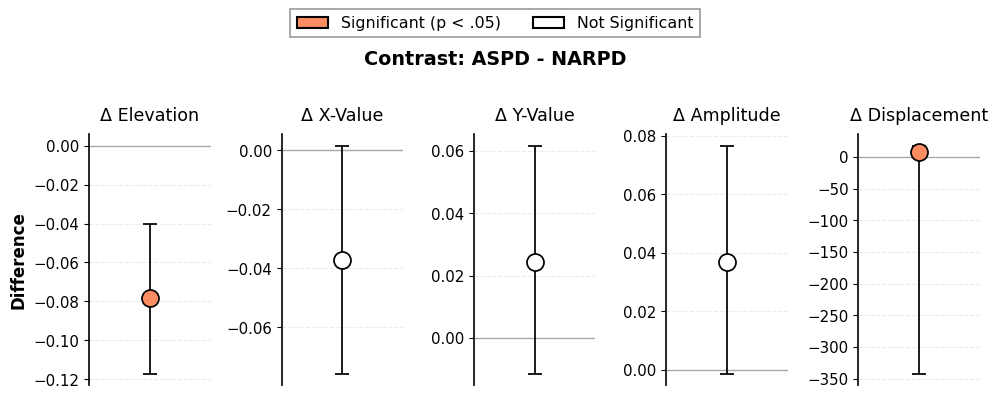

In [21]:
# Visualize measure contrasts
fig = results_meas_contrast.plot_contrast()

## 7. Customizing Visualizations

All plot functions support extensive customization:

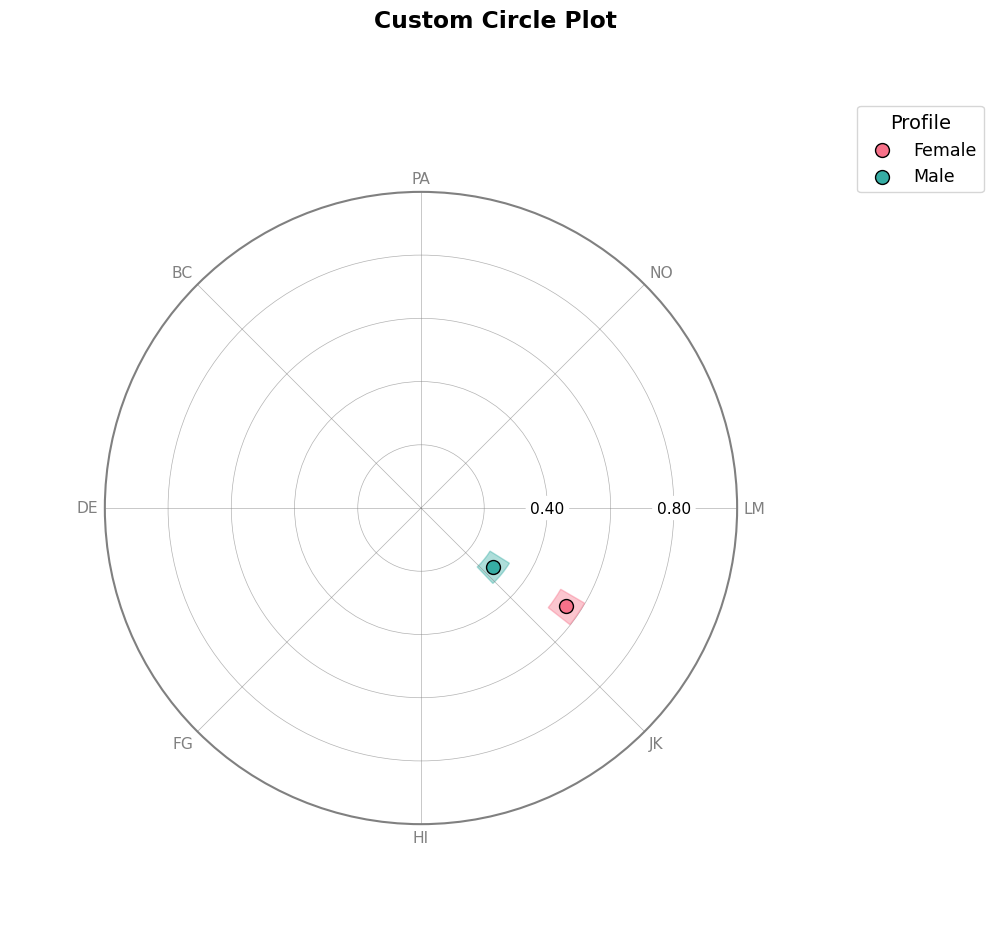

In [22]:
# Circle plot with custom options
fig = results_group.plot_circle(
    colors="husl",  # Color palette
    fontsize=14,  # Font size
    figsize=(10, 10),  # Figure size
    title="Custom Circle Plot",
    angle_labels=scales,  # Custom angle labels
)

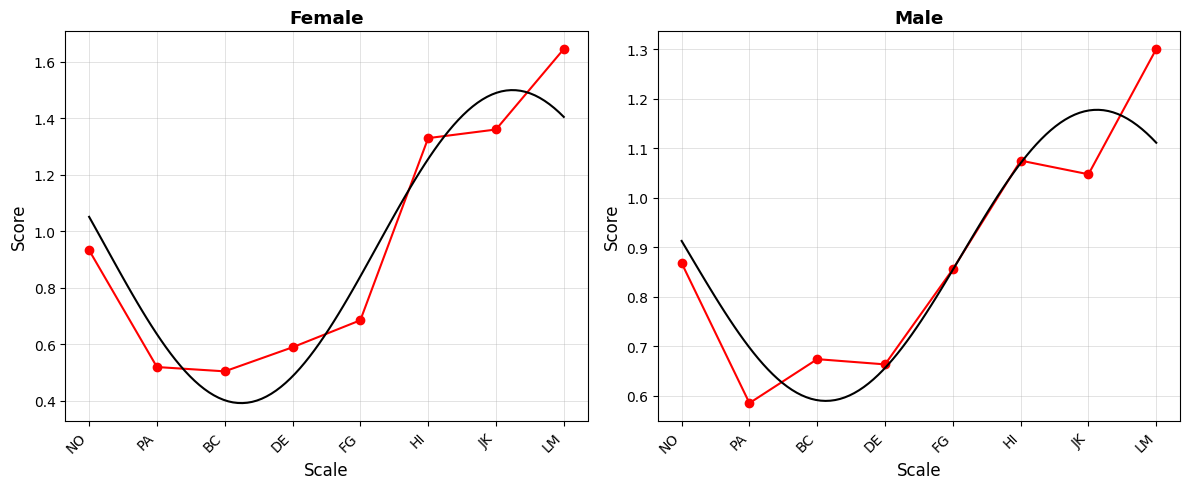

In [23]:
# Curve plot with custom options
fig = results_group.plot_curve(
    angle_labels=scales,
    base_size=12,
    figsize=(12, 5),
)

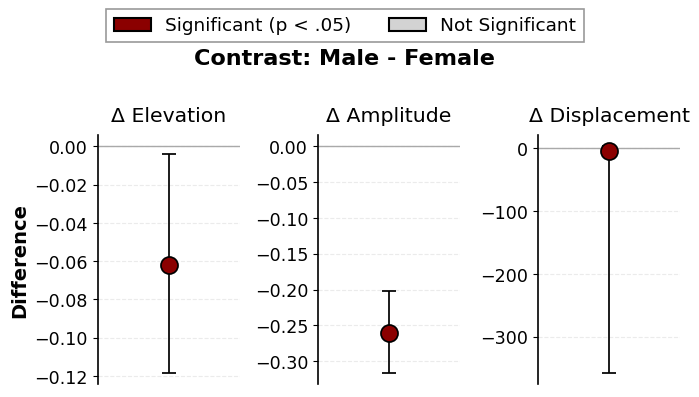

In [24]:
# Contrast plot with custom colors
fig = results_contrast.plot_contrast(
    sig_color="darkred",
    ns_color="lightgray",
    fontsize=14,
    drop_xy=True,
)

## 8. Saving Plots

All plots return matplotlib Figure objects that can be saved:

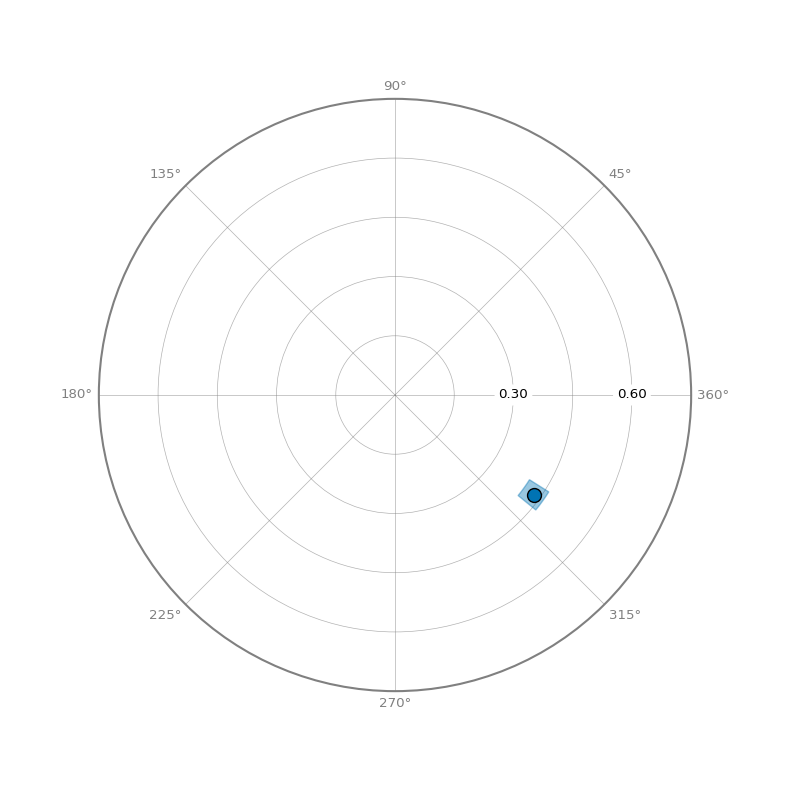

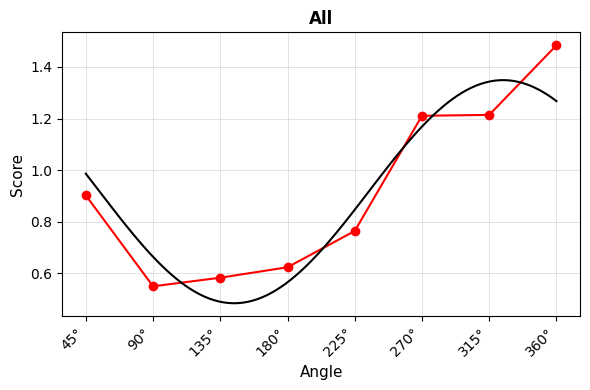

In [25]:
# Save plots
fig1 = results.plot_circle()
fig1.savefig("circle_plot.png", dpi=300, bbox_inches="tight")

fig2 = results.plot_curve()
fig2.savefig("curve_plot.png", dpi=300, bbox_inches="tight")

## Summary

The circumplex package provides a comprehensive toolkit for SSM analysis:

- **`ssm_analyze()`**: Performs mean-based or correlation-based SSM analysis
- **`plot_circle()`**: Visualizes amplitude/displacement on circular plots
- **`plot_curve()`**: Shows fitted curves with observed data
- **`plot_contrast()`**: Displays parameter differences between groups

All functions support:
- Single or multiple groups
- Single or multiple measures
- Bootstrap confidence intervals
- Contrast analyses
- Extensive customization options